# 03. Model Training & Selection
In this notebook, we will train and evaluate multiple models: Random Forest, XGBoost, and LightGBM. We will compare their metrics (RMSE, MAE, MAPE, R2) and select the best model for our dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings = __import__("warnings")
warnings.filterwarnings("ignore")

## 1. Load Processed Data

In [2]:
train_df = pd.read_csv("../Dataset/processed/train.csv")
val_df = pd.read_csv("../Dataset/processed/val.csv")
test_df = pd.read_csv("../Dataset/processed/test.csv")

features = ["day_of_week", "is_weekend", "month", "day", "lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]
target = "consumption_liters"

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

## 2. Train Multiple Models
We will instantiate and train Random Forest, XGBoost, and LightGBM.

In [3]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

Training Random Forest...


Training XGBoost...
Training LightGBM...


## 3. Evaluate Models on Test Set

In [4]:
def evaluate(model, X, y):
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    mape = np.mean(np.abs((y - preds) / y)) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}

results = []
for name, model in models.items():
    metrics = evaluate(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

,RMSE,MAE,MAPE,R2
Model,,,,
Random Forest,4173.428088,3488.801688,35.594483,-0.040837
XGBoost,4449.567736,3611.599558,36.001749,-0.183130
LightGBM,4242.013466,3476.498004,34.783737,-0.075328


## 4. Compare Performance Visually

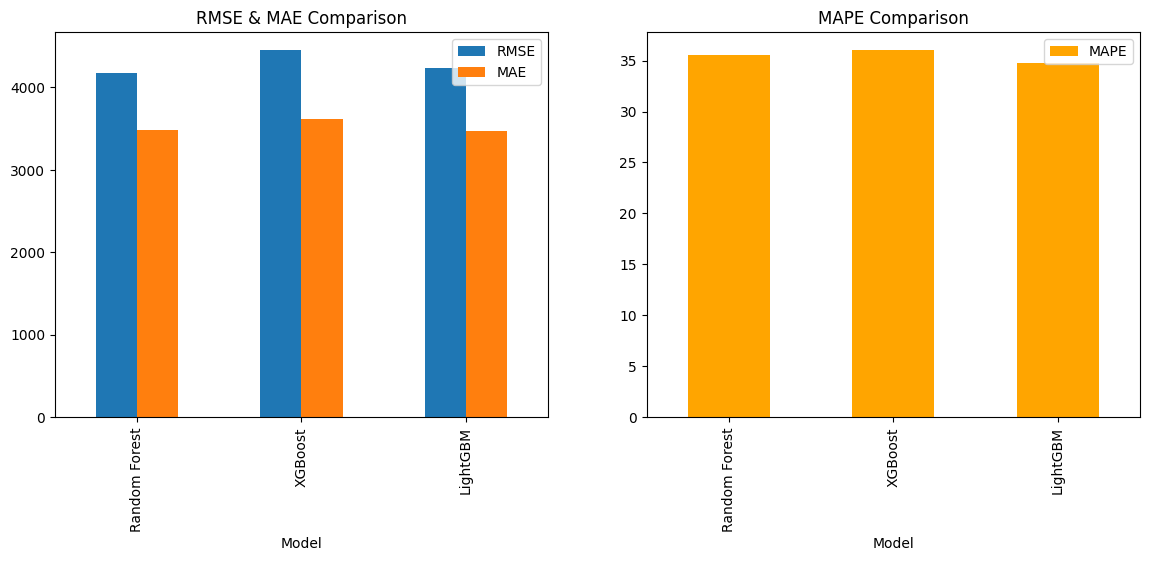

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0], title="RMSE & MAE Comparison")
results_df[["MAPE"]].plot(kind="bar", ax=axes[1], title="MAPE Comparison", color="orange")
plt.show()

## 5. Select Best Model and Save
Based on the evaluation, we save the best performing model (lowest RMSE/MAPE).

In [6]:
best_model_name = results_df["RMSE"].idxmin()
print(f"The best model is {best_model_name}")
best_model = models[best_model_name]

os.makedirs("../models", exist_ok=True)
with open("../models/xgboost_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("Model saved to ../models/xgboost_model.pkl")

The best model is Random Forest
Model saved to ../models/xgboost_model.pkl
